# MDI3003 – Advanced Predictive Analytics
## Lab 05: Product and Brand Sentiment Prediction from Tweet Data

**Complete step-by-step notebook**

This notebook follows the faculty manual:
- Preferred core dataset: Twitter US Airline Sentiment
- 3-class target: negative / neutral / positive
- Leakage-safe preprocessing
- DummyClassifier and VADER baselines
- TF-IDF + MultinomialNB
- TF-IDF + Logistic Regression
- TF-IDF + LinearSVC
- Cross-validation model selection using Macro F1
- Locked-test evaluation
- Required visualizations
- Product/entity analysis
- 5–10 error inspection
- Linguistic challenge analysis
- Controlled preprocessing ablation
- Save/reload verification
- Optional BiLSTM extension
- Optional BERTweet/Twitter-RoBERTa extension
- Optional cross-dataset label-harmonization record
- Reproducibility and responsible-use notes

**Important:** Do not use the final test set for model selection or tuning.


## 1. Research question

**How accurately can positive, neutral, and negative sentiment toward a product/service entity be predicted from tweet text, and which errors matter most for business interpretation?**

The output is intended for aggregate monitoring and analysis, not autonomous action against individual users.


In [1]:
# Cell 1 – Install required core package
# Run this cell once if VADER is not already installed.

!pip -q install vaderSentiment


In [2]:
# Cell 2 – Imports and reproducibility

import os
import re
import json
import time
import platform
import random
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score, precision_recall_fscore_support
)

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

OUT = "lab05_outputs"
os.makedirs(OUT, exist_ok=True)

print("Python:", platform.python_version())
print("Seed:", SEED)
print("Output folder:", OUT)


Python: 3.13.9
Seed: 42
Output folder: lab05_outputs


## 2. Dataset configuration

The faculty manual recommends the **Twitter US Airline Sentiment** dataset for the 3-hour core because it contains sentiment toward identifiable service entities.

For the standard Kaggle CSV, the important columns are usually:
- `text` → tweet text
- `airline_sentiment` → target
- `tweet_id` → identifier
- `airline` → entity

If your instructor-provided file uses different names, change only the configuration below after checking `raw.columns`.


In [3]:
# Cell 3 – Load the dataset

DATA_PATH = "Tweets.csv"      

raw = pd.read_csv(DATA_PATH)

print("Shape:", raw.shape)
print("\nColumns:")
print(raw.columns.tolist())
print("\nFirst 3 rows:")
display(raw.head(3))


Shape: (14640, 15)

Columns:
['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']

First 3 rows:


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)


In [4]:
# Cell 4 – Configure columns after checking the schema

TEXT_COL = "text"
TARGET_COL = "airline_sentiment"
ID_COL = "tweet_id"
ENTITY_COL = "airline"

required = {TEXT_COL, TARGET_COL}
missing = required - set(raw.columns)

assert not missing, f"Missing required columns: {missing}"

keep_cols = [c for c in [ID_COL, TEXT_COL, TARGET_COL, ENTITY_COL] if c in raw.columns]
df = raw[keep_cols].copy()

df = df.dropna(subset=[TEXT_COL, TARGET_COL])
df[TEXT_COL] = df[TEXT_COL].astype(str)

print("Working shape:", df.shape)
print("\nLabel counts:")
display(df[TARGET_COL].value_counts())


Working shape: (14640, 4)

Label counts:


airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

## 3. Dataset card / governance record

Record these items in the final report:
- dataset name and public source
- access date and version
- license/usage terms
- number of rows and class distribution
- train/validation/test definition
- duplicate and near-duplicate policy
- language/domain
- annotation method and likely label noise
- excluded privacy/leakage fields
- collection period and sampling limitations


In [5]:
# Cell 5 – Dataset card

dataset_card = {
    "dataset": "Twitter US Airline Sentiment",
    "source": "Instructor-approved public dataset / Kaggle source",
    "access_date": "2026-08-23",
    "version": "Record the downloaded/instructor-supplied version here",
    "license_usage": "Record the dataset page/license terms here",
    "rows_loaded": int(len(df)),
    "labels": sorted(df[TARGET_COL].dropna().unique().tolist()),
    "text_column": TEXT_COL,
    "target_column": TARGET_COL,
    "entity_column": ENTITY_COL if ENTITY_COL in df.columns else None,
    "seed": SEED,
    "domain": "Airline/service customer tweets",
    "collection_period": "February 2015",
    "notes": "Older Twitter corpus; may not represent current X/social-media language."
}

print(json.dumps(dataset_card, indent=2))
with open(os.path.join(OUT, "dataset_card.json"), "w", encoding="utf-8") as f:
    json.dump(dataset_card, f, indent=2)


{
  "dataset": "Twitter US Airline Sentiment",
  "source": "Instructor-approved public dataset / Kaggle source",
  "access_date": "2026-08-23",
  "version": "Record the downloaded/instructor-supplied version here",
  "license_usage": "Record the dataset page/license terms here",
  "rows_loaded": 14640,
  "labels": [
    "negative",
    "neutral",
    "positive"
  ],
  "text_column": "text",
  "target_column": "airline_sentiment",
  "entity_column": "airline",
  "seed": 42,
  "domain": "Airline/service customer tweets",
  "collection_period": "February 2015",
  "notes": "Older Twitter corpus; may not represent current X/social-media language."
}


## 4. Data audit

The audit must include:
- shape
- columns
- label counts
- nulls
- duplicate tweet IDs
- duplicate text
- representative examples
- annotation metadata if present

Identifiers and annotation/post-label fields must not become predictors.


In [6]:
# Cell 6 – Audit

print("Shape:", df.shape)
print("\nNull values:")
display(df.isna().sum().to_frame("null_count"))

if ID_COL in df.columns:
    print("Duplicate tweet IDs:", int(df[ID_COL].duplicated().sum()))
else:
    print("Duplicate tweet IDs: ID column not present")

print("Duplicate raw text:", int(df[TEXT_COL].duplicated().sum()))

print("\nClass distribution:")
display(df[TARGET_COL].value_counts(dropna=False).to_frame("count"))

print("\nRepresentative examples:")
display(df[[TEXT_COL, TARGET_COL] + ([ENTITY_COL] if ENTITY_COL in df.columns else [])].sample(
    min(10, len(df)), random_state=SEED
))


Shape: (14640, 4)

Null values:


,null_count
tweet_id,0
text,0
airline_sentiment,0
airline,0


Duplicate tweet IDs: 155
Duplicate raw text: 213

Class distribution:


,count
airline_sentiment,
negative,9178
neutral,3099
positive,2363



Representative examples:


,text,airline_sentiment,airline
4794,@SouthwestAir you're my early frontrunner for ...,positive,Southwest
10480,@USAirways how is it that my flt to EWR was Ca...,negative,US Airways
8067,@JetBlue what is going on with your BDL to DCA...,negative,Delta
8880,@JetBlue do they have to depart from Washingto...,neutral,Delta
8292,@JetBlue I can probably find some of them. Are...,negative,Delta
927,@united still waiting to hear back. My wallet ...,negative,United
3165,@united Yes my flight was rebooked. I'm just l...,negative,United
7894,@JetBlue Thank you ! What about Paris ? Could ...,neutral,Delta
2818,"@united not 100% sure, however my ticket inclu...",negative,United
9145,@usairways great crew for flight 504 PHX to YV...,positive,US Airways


In [7]:
# Cell 7 – Check for leakage / identifier columns

known_excluded = [
    "tweet_id", "username", "user", "location", "timezone", "coordinates",
    "sentiment_confidence", "negative_reason", "gold_reason"
]

present_excluded = [c for c in known_excluded if c in raw.columns]

print("Potential identifier/leakage fields found:")
print(present_excluded)

print("\nThese fields are excluded from the model unless explicitly justified for analysis.")


Potential identifier/leakage fields found:
['tweet_id']

These fields are excluded from the model unless explicitly justified for analysis.


## 5. Minimal tweet normalization

The manual requires minimal cleaning:
- normalize whitespace
- replace URLs with `<URL>`
- replace mentions with `<USER>`
- preserve negation
- preserve emojis
- preserve hashtags
- preserve punctuation
- preserve product/brand handles unless an ablation tests removal


In [8]:
# Cell 8 – Minimal tweet normalization

def normalize_tweet(text):
    text = str(text)
    text = re.sub(r"https?://\S+|www\.\S+", " <URL> ", text)
    text = re.sub(r"@\w+", " <USER> ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df[TEXT_COL].map(normalize_tweet)

print("Before:")
display(df[TEXT_COL].head(5))

print("\nAfter:")
display(df["clean_text"].head(5))

print("\nDuplicate cleaned text:", int(df["clean_text"].duplicated().sum()))


Before:


0                  @VirginAmerica What @dhepburn said.
1    @VirginAmerica plus you've added commercials t...
2    @VirginAmerica I didn't today... Must mean I n...
3    @VirginAmerica it's really aggressive to blast...
4    @VirginAmerica and it's a really big bad thing...
Name: text, dtype: object


After:


0                             <USER> What <USER> said.
1    <USER> plus you've added commercials to the ex...
2    <USER> I didn't today... Must mean I need to t...
3    <USER> it's really aggressive to blast obnoxio...
4      <USER> and it's a really big bad thing about it
Name: clean_text, dtype: object


Duplicate cleaned text: 336


## 6. Required visualizations – EDA


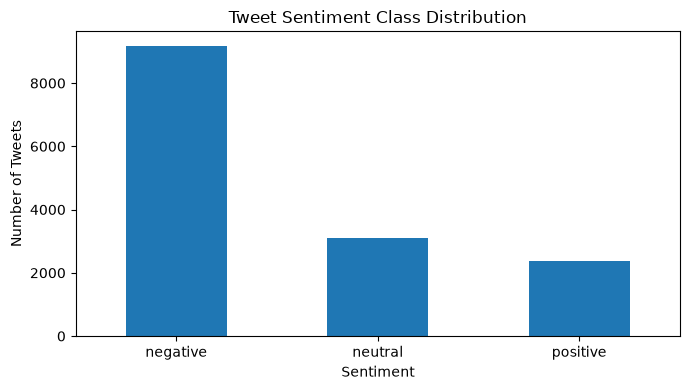

In [9]:
# Cell 9 – Class distribution

label_counts = df[TARGET_COL].value_counts()

plt.figure(figsize=(7, 4))
label_counts.plot(kind="bar")
plt.title("Tweet Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUT, "01_class_distribution.png"), dpi=200)
plt.show()


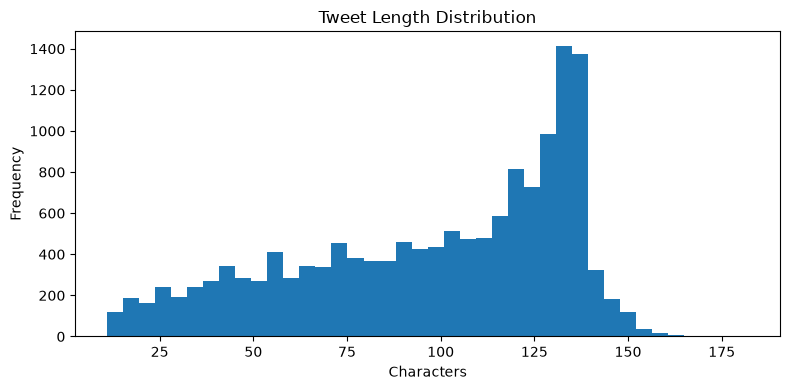

,value
count,14640.000000
mean,97.752732
std,36.378871
min,11.000000
25%,70.000000
50%,107.000000
75%,130.000000
max,182.000000


In [10]:
# Cell 10 – Tweet-length distribution

df["tweet_length"] = df["clean_text"].str.len()

plt.figure(figsize=(8, 4))
plt.hist(df["tweet_length"], bins=40)
plt.title("Tweet Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "02_tweet_length_distribution.png"), dpi=200)
plt.show()

display(df["tweet_length"].describe().to_frame("value"))


## 7. Fixed train/test split

For D2, create one fixed stratified split and save the row manifests.

All comparative classical models must use exactly the same split.


In [11]:
# Cell 11 – Frozen stratified split

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df[TARGET_COL]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_df.to_csv(os.path.join(OUT, "train_manifest.csv"), index=False)
test_df.to_csv(os.path.join(OUT, "test_manifest.csv"), index=False)

X_train = train_df["clean_text"]
y_train = train_df[TARGET_COL]

X_test = test_df["clean_text"]
y_test = test_df[TARGET_COL]

print("Train:", train_df.shape)
print("Test :", test_df.shape)
print("\nTrain labels:")
display(y_train.value_counts(normalize=False).to_frame("count"))


Train: (11712, 6)
Test : (2928, 6)

Train labels:


,count
airline_sentiment,
negative,7343
neutral,2479
positive,1890


## 8. Baseline 1 – DummyClassifier

This is the trivial baseline. The learned models should demonstrate clear improvement over it.


In [12]:
# Cell 12 – Dummy baseline

dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)

dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

dummy_macro = f1_score(y_test, dummy_pred, average="macro")
dummy_weighted = f1_score(y_test, dummy_pred, average="weighted")
dummy_acc = accuracy_score(y_test, dummy_pred)

print("Dummy Accuracy:", round(dummy_acc, 4))
print("Dummy Macro F1:", round(dummy_macro, 4))
print("Dummy Weighted F1:", round(dummy_weighted, 4))


Dummy Accuracy: 0.6267
Dummy Macro F1: 0.2568
Dummy Weighted F1: 0.4829


## 9. Baseline 2 – VADER

VADER is a no-training social-media sentiment baseline.

The standard thresholds used here are:
- compound >= 0.05 → positive
- compound <= -0.05 → negative
- otherwise → neutral

This is a baseline only; it may struggle with domain-specific terminology, context and sarcasm.


In [13]:
# Cell 13 – VADER baseline

analyzer = SentimentIntensityAnalyzer()

def vader_label(text):
    compound = analyzer.polarity_scores(str(text))["compound"]
    if compound >= 0.05:
        return "positive"
    if compound <= -0.05:
        return "negative"
    return "neutral"

assert set(y_train.unique()) <= {"negative", "neutral", "positive"}

vader_pred = X_test.map(vader_label)

vader_macro = f1_score(y_test, vader_pred, average="macro")
vader_weighted = f1_score(y_test, vader_pred, average="weighted")
vader_acc = accuracy_score(y_test, vader_pred)

print("VADER Accuracy:", round(vader_acc, 4))
print("VADER Macro F1:", round(vader_macro, 4))
print("VADER Weighted F1:", round(vader_weighted, 4))


VADER Accuracy: 0.5523
VADER Macro F1: 0.5206
VADER Weighted F1: 0.573


## 10. Classical TF-IDF pipelines

Required learned models:
1. MultinomialNB – recommended rapid probabilistic comparison
2. Logistic Regression – mandatory
3. LinearSVC – mandatory

TF-IDF is fitted **inside each Pipeline**, preventing vocabulary/statistical leakage.


In [14]:
# Cell 14 – Define classical pipelines

models = {
    "MultinomialNB": Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.98,
            sublinear_tf=True
        )),
        ("clf", MultinomialNB(alpha=0.5))
    ]),

    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.98,
            sublinear_tf=True
        )),
        ("clf", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=SEED
        ))
    ]),

    "LinearSVC": Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.98,
            sublinear_tf=True
        )),
        ("clf", LinearSVC(
            class_weight="balanced",
            random_state=SEED
        ))
    ])
}

print("Models:", list(models.keys()))


Models: ['MultinomialNB', 'Logistic Regression', 'LinearSVC']


In [15]:
# Cell 15 – Same 5-fold CV for all learned models

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

cv_rows = []

for name, pipe in models.items():
    start = time.perf_counter()

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "macro_f1": "f1_macro",
            "weighted_f1": "f1_weighted",
            "accuracy": "accuracy"
        },
        n_jobs=-1,
        return_train_score=False
    )

    elapsed = time.perf_counter() - start

    cv_rows.append({
        "model": name,
        "macro_f1_mean": scores["test_macro_f1"].mean(),
        "macro_f1_sd": scores["test_macro_f1"].std(),
        "weighted_f1_mean": scores["test_weighted_f1"].mean(),
        "accuracy_mean": scores["test_accuracy"].mean(),
        "fit_time_mean": scores["fit_time"].mean(),
        "wall_time_sec": elapsed
    })

cv_results = pd.DataFrame(cv_rows).sort_values(
    "macro_f1_mean", ascending=False
).reset_index(drop=True)

display(cv_results)

cv_results.to_csv(
    os.path.join(OUT, "cv_results.csv"),
    index=False
)


,model,macro_f1_mean,macro_f1_sd,weighted_f1_mean,accuracy_mean,fit_time_mean,wall_time_sec
0,Logistic Regression,0.744384,0.008241,0.795471,0.792776,3.168629,13.951499
1,LinearSVC,0.739502,0.011703,0.796877,0.800631,2.845718,3.566686
2,MultinomialNB,0.585816,0.015062,0.690117,0.736339,1.775882,14.566646


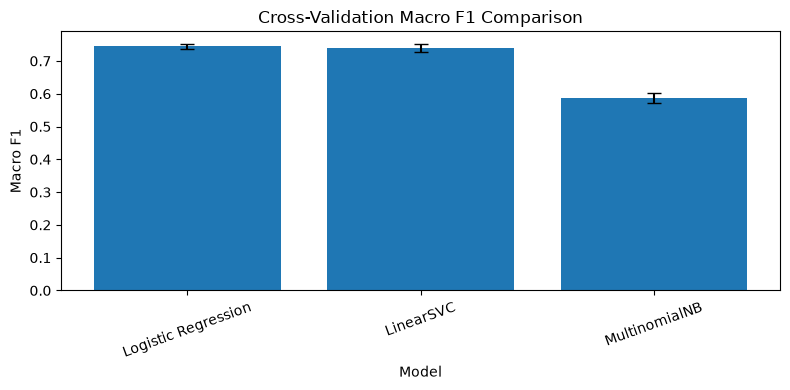

In [16]:
# Cell 16 – CV model comparison plot

plt.figure(figsize=(8, 4))
plt.bar(
    cv_results["model"],
    cv_results["macro_f1_mean"],
    yerr=cv_results["macro_f1_sd"],
    capsize=5
)
plt.title("Cross-Validation Macro F1 Comparison")
plt.xlabel("Model")
plt.ylabel("Macro F1")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(OUT, "03_cv_model_comparison.png"), dpi=200)
plt.show()


## 11. Top terms / n-grams by class

This visualization is based on the **training data only**, as required by the manual.


In [17]:
# Cell 17 – Top TF-IDF terms by class using training data only

top_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.98,
    sublinear_tf=True
)

Xtr_tfidf = top_vectorizer.fit_transform(X_train)
terms = np.array(top_vectorizer.get_feature_names_out())

for label in sorted(y_train.unique()):
    mask = (y_train.to_numpy() == label)
    mean_scores = np.asarray(Xtr_tfidf[mask].mean(axis=0)).ravel()
    top_idx = mean_scores.argsort()[-15:][::-1]

    top_terms = pd.DataFrame({
        "term": terms[top_idx],
        "mean_tfidf": mean_scores[top_idx]
    })

    print(f"Top terms for {label}:")
    display(top_terms)


Top terms for negative:


,term,mean_tfidf
0,to,0.030865
1,the,0.025437
2,flight,0.021877
3,and,0.021197
4,on,0.021031
5,you,0.019863
6,for,0.019844
7,my,0.018957
8,is,0.018296
9,in,0.014963


Top terms for neutral:


,term,mean_tfidf
0,to,0.028070
1,url,0.024549
2,you,0.021295
3,the,0.020577
4,on,0.017831
5,can,0.016712
6,flight,0.016209
7,for,0.015230
8,is,0.014796
9,it,0.014333


Top terms for positive:


,term,mean_tfidf
0,thanks,0.049179
1,thank,0.042802
2,thank you,0.042111
3,you,0.039623
4,user thanks,0.037287
5,user thank,0.031530
6,the,0.027737
7,for,0.023260
8,to,0.021087
9,great,0.018022


## 12. Controlled preprocessing ablation

The manual requires one controlled ablation, for example:
- preserve hashtags/emojis
- versus remove hashtags/emojis

Only one preprocessing choice is changed; the split and evaluation procedure remain identical.


In [18]:
# Cell 18 – Ablation: preserve hashtags/emojis vs remove them

def remove_hashtags_emojis(text):
    text = re.sub(r"#\w+", " ", str(text))
    # Conservative emoji removal for the ablation only.
    text = re.sub(
        r"[\U0001F300-\U0001FAFF\U00002600-\U000027BF]",
        " ",
        text
    )
    text = re.sub(r"\s+", " ", text).strip()
    return text

X_train_ablation = X_train.map(remove_hashtags_emojis)
X_test_ablation = X_test.map(remove_hashtags_emojis)

ablation_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.98,
        sublinear_tf=True
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=SEED
    ))
])

ablation_model.fit(X_train_ablation, y_train)
ablation_pred = ablation_model.predict(X_test_ablation)

print("Ablation Macro F1:",
      round(f1_score(y_test, ablation_pred, average="macro"), 4))

print("Ablation Accuracy:",
      round(accuracy_score(y_test, ablation_pred), 4))

print("\nThis should be compared with the final Logistic Regression result.")


Ablation Macro F1: 0.7398
Ablation Accuracy: 0.7879

This should be compared with the final Logistic Regression result.


## 13. Select the best classical model

Selection is based on **CV Macro F1**, not final-test performance.

Class-wise recall and stability are secondary evidence.


In [19]:
# Cell 19 – Model selection

best_name = cv_results.iloc[0]["model"]
best_model = models[best_name]

print("Selected model:", best_name)
print("Selection metric: CV Macro F1")
print("CV Macro F1:", round(cv_results.iloc[0]["macro_f1_mean"], 4))
print("CV Macro F1 SD:", round(cv_results.iloc[0]["macro_f1_sd"], 4))


Selected model: Logistic Regression
Selection metric: CV Macro F1
CV Macro F1: 0.7444
CV Macro F1 SD: 0.0082


## 14. Locked-test evaluation

Now fit the selected pipeline on the complete training partition and evaluate once on the untouched test set.


In [20]:
# Cell 20 – Fit selected model and evaluate on locked test set

best_model.fit(X_train, y_train)
pred = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, pred)
test_macro_f1 = f1_score(y_test, pred, average="macro")
test_weighted_f1 = f1_score(y_test, pred, average="weighted")

print("Selected:", best_name)
print("Test Accuracy:", round(test_accuracy, 4))
print("Test Macro F1:", round(test_macro_f1, 4))
print("Test Weighted F1:", round(test_weighted_f1, 4))

print("\nClassification report:")
print(classification_report(y_test, pred, digits=4))


Selected: Logistic Regression
Test Accuracy: 0.7917
Test Macro F1: 0.7442
Test Weighted F1: 0.7958

Classification report:
              precision    recall  f1-score   support

    negative     0.8905    0.8420    0.8655      1835
     neutral     0.5904    0.7161    0.6472       620
    positive     0.7460    0.6956    0.7199       473

    accuracy                         0.7917      2928
   macro avg     0.7423    0.7512    0.7442      2928
weighted avg     0.8036    0.7917    0.7958      2928



In [21]:
# Cell 21 – Per-class metrics table

precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    pred,
    labels=["negative", "neutral", "positive"],
    zero_division=0
)

per_class = pd.DataFrame({
    "class": ["negative", "neutral", "positive"],
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "support": support
})

display(per_class)
per_class.to_csv(os.path.join(OUT, "per_class_metrics.csv"), index=False)


,class,precision,recall,f1,support
0,negative,0.890490,0.841962,0.865546,1835
1,neutral,0.590426,0.716129,0.647230,620
2,positive,0.746032,0.695560,0.719912,473


## 15. Count confusion matrix


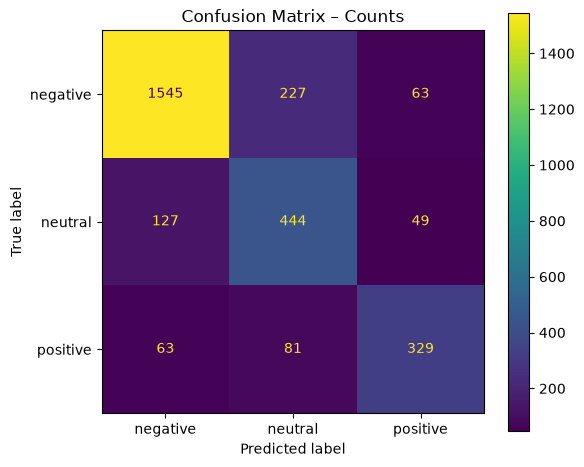

In [22]:
# Cell 22 – Count confusion matrix

labels = ["negative", "neutral", "positive"]
cm = confusion_matrix(y_test, pred, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax)
ax.set_title("Confusion Matrix – Counts")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "04_confusion_matrix_counts.png"), dpi=200)
plt.show()


## 16. Row-normalized confusion matrix


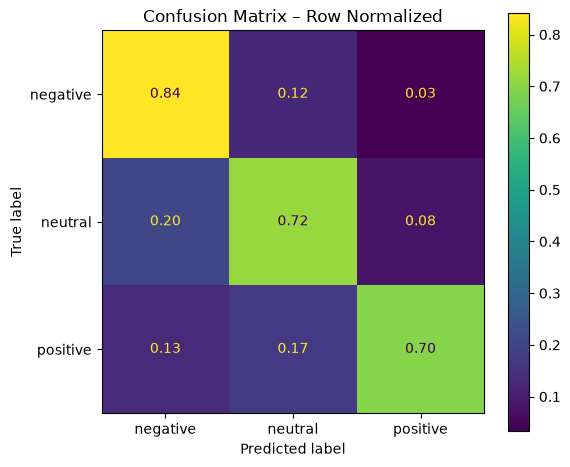

In [23]:
# Cell 23 – Row-normalized confusion matrix

cm_norm = confusion_matrix(
    y_test,
    pred,
    labels=labels,
    normalize="true"
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, values_format=".2f")
ax.set_title("Confusion Matrix – Row Normalized")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "05_confusion_matrix_normalized.png"), dpi=200)
plt.show()


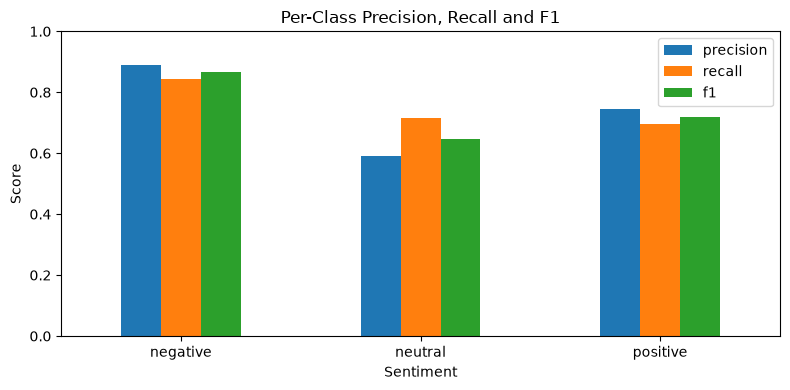

In [24]:
# Cell 24 – Per-class precision / recall / F1 plot

metric_plot = per_class.set_index("class")[["precision", "recall", "f1"]]

ax = metric_plot.plot(kind="bar", figsize=(8, 4))
ax.set_title("Per-Class Precision, Recall and F1")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUT, "06_per_class_metrics.png"), dpi=200)
plt.show()


## 17. Save test predictions

Do not expose raw usernames, coordinates or other identifiers in the report.


In [25]:
# Cell 25 – Save predictions

pred_df_cols = [
    c for c in [ID_COL, TEXT_COL, TARGET_COL, ENTITY_COL]
    if c in test_df.columns
]

pred_df = test_df[pred_df_cols].copy()
pred_df["prediction"] = pred
pred_df["correct"] = pred_df[TARGET_COL].eq(pred_df["prediction"])

pred_df.to_csv(
    os.path.join(OUT, "test_predictions.csv"),
    index=False
)

display(pred_df.head(10))


,tweet_id,text,airline_sentiment,airline,prediction,correct
0,568803260569690112,@united past,neutral,United,negative,False
1,569310070825226241,@JetBlue would you say a delay is more likely?...,positive,Delta,positive,True
2,568155066668060672,"@JetBlue I cheated on you, and I'm sorry. I'll...",negative,Delta,negative,True
3,570247551368241153,@united disappointed that u didnt honor my $10...,negative,United,negative,True
4,567783713833234432,@USAirways The airline is embarrassing itself....,negative,US Airways,negative,True
5,569646613183885312,@AmericanAir my flight has been delayed &amp; ...,negative,American,negative,True
6,567880317345771520,@united This link in your tweet goes to someon...,neutral,United,negative,False
7,568611966937214976,@SouthwestAir BETSY is the BESTY! Gettin' stuc...,negative,Southwest,negative,True
8,569783738210525184,@USAirways How many agents do you have working...,negative,US Airways,negative,True
9,569935276346351616,@SouthwestAir When will the flight resume? I d...,negative,Southwest,neutral,False


## 18. Error analysis – inspect at least 5–10 errors

The manual requires inspection of incorrectly classified examples and discussion of likely failure mechanisms.


In [26]:
# Cell 26 – Ten representative errors

errors = pred_df[~pred_df["correct"]].copy()

print("Total errors:", len(errors))

error_sample = errors.sample(
    min(10, len(errors)),
    random_state=SEED
)

display(error_sample)
error_sample.to_csv(
    os.path.join(OUT, "inspected_errors_10.csv"),
    index=False
)


Total errors: 610


,tweet_id,text,airline_sentiment,airline,prediction,correct
396,568168460468895745,@united well it IS John Hughes' birthday. But ...,positive,United,negative,False
1117,569483642931691520,@SouthwestAir do you ever reinstate Cancelled ...,negative,Southwest,neutral,False
310,569347934866636800,@SouthwestAir are you hiring for flight attend...,neutral,Southwest,negative,False
2874,568935917341286400,@USAirways @AmericanAir thought u merged but #...,negative,US Airways,neutral,False
1329,568448023845572608,@JetBlue yes he and all the princesses. Trying...,neutral,Delta,negative,False
804,570115366023770112,@united Thanks for the lack of help and the ca...,negative,United,positive,False
2390,570251814970515456,@AmericanAir I need refund.,negative,American,neutral,False
1594,568049335235010562,@united Club in Denver is dope 👌,positive,United,neutral,False
2824,570010327036735488,@AmericanAir I'll try to have a great week onc...,negative,American,positive,False
1429,568895856750899202,@united how long does it take for customer fee...,neutral,United,negative,False


## 19. Linguistic challenge analysis

Inspect:
- negation
- sarcasm/irony
- emoji-heavy sentiment
- hashtags
- product handles
- slang/abbreviations
- spelling variation/elongation
- mixed sentiment
- neutral factual statements
- quoted/retweeted content
- code-mixing/non-English text
- domain-specific terms

The challenge subset must not be used for tuning.


In [27]:
# Cell 27 – Heuristic challenge flags for error analysis

challenge_df = pred_df.copy()

# Negation
challenge_df["negation"] = challenge_df[TEXT_COL].str.contains(
    r"\b(?:not|no|never|n't|neither|nothing)\b",
    case=False,
    regex=True,
    na=False
)

# Sarcasm / irony hints
challenge_df["sarcasm_hint"] = challenge_df[TEXT_COL].str.contains(
    r"\b(?:sarcasm|sarcastic|yeah right)\b|/s\b",
    case=False,
    regex=True,
    na=False
)

# Emoji
challenge_df["emoji_heavy"] = challenge_df[TEXT_COL].str.contains(
    r"[\U0001F300-\U0001FAFF\u2600-\u27BF]",
    regex=True,
    na=False
)

# Hashtag
challenge_df["hashtag"] = challenge_df[TEXT_COL].str.contains(
    r"#\w+",
    regex=True,
    na=False
)

# Product / brand handle
challenge_df["product_handle"] = challenge_df[TEXT_COL].str.contains(
    r"@\w+",
    regex=True,
    na=False
)

# Repeated characters
def has_elongation(text):
    return bool(re.search(r"(.)\1{2,}", str(text)))

challenge_df["elongation"] = challenge_df[TEXT_COL].map(
    has_elongation
)

# Mixed sentiment
positive_words = r"\b(?:love|great|good|happy)\b"
negative_words = r"\b(?:hate|bad|terrible|awful|worst|angry)\b"

challenge_df["mixed_sentiment_hint"] = (
    challenge_df[TEXT_COL].str.contains(
        positive_words,
        case=False,
        regex=True,
        na=False
    )
    &
    challenge_df[TEXT_COL].str.contains(
        negative_words,
        case=False,
        regex=True,
        na=False
    )
)

challenge_flags = [
    "negation",
    "sarcasm_hint",
    "emoji_heavy",
    "hashtag",
    "product_handle",
    "elongation",
    "mixed_sentiment_hint"
]

challenge_results = []

for col in challenge_flags:

    subset = challenge_df[challenge_df[col]]

    if len(subset) == 0:
        continue

    challenge_results.append({
        "challenge_type": col,
        "N": len(subset),
        "accuracy": subset["correct"].mean(),
        "error_rate": 1 - subset["correct"].mean()
    })

challenge_results = pd.DataFrame(challenge_results)

display(challenge_results)

challenge_results.to_csv(
    os.path.join(OUT, "challenge_analysis.csv"),
    index=False
)

,challenge_type,N,accuracy,error_rate
0,negation,615,0.874797,0.125203
1,sarcasm_hint,3,0.333333,0.666667
2,emoji_heavy,108,0.666667,0.333333
3,hashtag,452,0.780973,0.219027
4,product_handle,2928,0.791667,0.208333
5,elongation,330,0.781818,0.218182
6,mixed_sentiment_hint,6,0.833333,0.166667


### Important note on challenge flags

These are **screening heuristics**, not gold-standard linguistic annotations. For the final report, manually verify representative examples and explain when a challenge type is absent or incorrectly detected.


## 20. Product/entity analysis

For the airline dataset, `airline` is the entity field.

The manual recommends a minimum support threshold before comparing entities. This notebook uses **30 held-out tweets per entity** as an example threshold.


In [28]:
# Cell 28 – Entity sentiment distribution and error rate

MIN_SUPPORT = 30

if ENTITY_COL in pred_df.columns:
    entity_counts = pred_df[ENTITY_COL].value_counts()
    valid_entities = entity_counts[entity_counts >= MIN_SUPPORT].index

    entity_analysis = (
        pred_df[pred_df[ENTITY_COL].isin(valid_entities)]
        .groupby(ENTITY_COL)
        .agg(
            N=("correct", "size"),
            accuracy=("correct", "mean")
        )
    )

    entity_analysis["error_rate"] = 1 - entity_analysis["accuracy"]

    entity_sentiment = pd.crosstab(
        pred_df[pred_df[ENTITY_COL].isin(valid_entities)][ENTITY_COL],
        pred_df[pred_df[ENTITY_COL].isin(valid_entities)]["prediction"],
        normalize="index"
    )

    print("Entity performance:")
    display(entity_analysis.sort_values("N", ascending=False))

    print("Entity predicted sentiment distribution:")
    display(entity_sentiment)

    entity_analysis.to_csv(
        os.path.join(OUT, "entity_error_analysis.csv")
    )
    entity_sentiment.to_csv(
        os.path.join(OUT, "entity_sentiment_distribution.csv")
    )
else:
    print("No entity column available; entity analysis skipped.")


Entity performance:


,N,accuracy,error_rate
airline,,,
United,774,0.788114,0.211886
US Airways,565,0.824779,0.175221
American,535,0.828037,0.171963
Southwest,506,0.758893,0.241107
Delta,456,0.776316,0.223684
Virgin America,92,0.663043,0.336957


Entity predicted sentiment distribution:


prediction,negative,neutral,positive
airline,,,
American,0.646729,0.242991,0.110280
Delta,0.447368,0.339912,0.212719
Southwest,0.450593,0.324111,0.225296
US Airways,0.734513,0.168142,0.097345
United,0.653747,0.224806,0.121447
Virgin America,0.391304,0.369565,0.239130


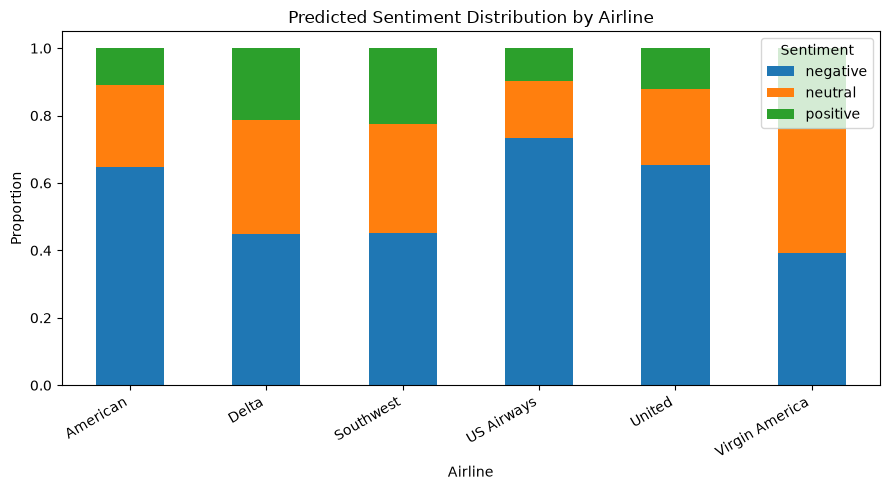

In [29]:
# Cell 29 – Entity sentiment plot

if ENTITY_COL in pred_df.columns:
    plot_entity = pd.crosstab(
        pred_df[ENTITY_COL],
        pred_df["prediction"],
        normalize="index"
    )

    ax = plot_entity.plot(
        kind="bar",
        stacked=True,
        figsize=(9, 5)
    )
    ax.set_title("Predicted Sentiment Distribution by Airline")
    ax.set_xlabel("Airline")
    ax.set_ylabel("Proportion")
    ax.legend(title="Sentiment")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT, "07_entity_sentiment_distribution.png"), dpi=200)
    plt.show()


## 21. Optional confidence / abstention analysis

Logistic Regression provides probabilities. LinearSVC does not provide calibrated probabilities by default.

Use this only if the selected model supports `predict_proba`, and choose any review threshold using training/validation evidence rather than the final test set.


In [30]:
# Cell 30 – Confidence analysis

if hasattr(best_model, "predict_proba"):

    proba = best_model.predict_proba(X_test)
    max_prob = proba.max(axis=1)

    confidence_df = pd.DataFrame({
        "true": y_test.to_numpy(),
        "prediction": pred,
        "max_probability": max_prob
    })

    confidence_df["correct"] = (
        confidence_df["true"] ==
        confidence_df["prediction"]
    )

    print(
        "Mean maximum probability:",
        round(max_prob.mean(), 4)
    )

    confidence_bins = pd.qcut(
        confidence_df["max_probability"],
        q=5,
        duplicates="drop"
    )

    confidence_summary = (
        confidence_df
        .groupby(confidence_bins, observed=True)["correct"]
        .agg(
            accuracy="mean",
            N="count"
        )
        .reset_index()
    )

    display(confidence_summary)

else:
    print(
        "Selected model does not expose calibrated probabilities."
    )

Mean maximum probability: 0.6948


,max_probability,accuracy,N
0,"(0.34299999999999997, 0.526]",0.535836,586
1,"(0.526, 0.638]",0.721368,585
2,"(0.638, 0.754]",0.805461,586
3,"(0.754, 0.871]",0.928205,585
4,"(0.871, 0.998]",0.967577,586


## 22. Save and reload verification

The manual requires the selected pipeline to be saved and reloaded, with matching predictions on a fixed sample.


In [31]:
# Cell 31 – Save and reload

MODEL_PATH = os.path.join(OUT, "selected_pipeline.joblib")

joblib.dump(best_model, MODEL_PATH)

reloaded = joblib.load(MODEL_PATH)

original_small = best_model.predict(X_test.iloc[:20])
reloaded_small = reloaded.predict(X_test.iloc[:20])

assert np.array_equal(
    original_small,
    reloaded_small
), "Reloaded predictions do not match!"

print("Saved:", MODEL_PATH)
print("Reload verification: PASSED")


Saved: lab05_outputs\selected_pipeline.joblib
Reload verification: PASSED


## 23. Predict new tweets

Use this only for demonstration. These predictions should be interpreted as model outputs, not definitive judgments about individual users.


In [32]:
# Cell 32 – New tweet prediction

new_tweets = [
    "The flight was excellent and the staff were very helpful!",
    "My flight was delayed again. This service is terrible.",
    "My flight from New York to Chicago is at 6 PM."
]

new_clean = [normalize_tweet(x) for x in new_tweets]
new_pred = reloaded.predict(new_clean)

new_results = pd.DataFrame({
    "tweet": new_tweets,
    "predicted_sentiment": new_pred
})

display(new_results)
new_results.to_csv(
    os.path.join(OUT, "new_tweet_predictions.csv"),
    index=False
)


,tweet,predicted_sentiment
0,The flight was excellent and the staff were ve...,positive
1,My flight was delayed again. This service is t...,negative
2,My flight from New York to Chicago is at 6 PM.,negative


## 24. Final core results table

This produces the main table needed for the record/report.


In [33]:
# Cell 33 – Final results table

baseline_results = pd.DataFrame([
    {
        "model": "DummyClassifier",
        "representation": "None",
        "CV Macro F1 mean": np.nan,
        "CV Macro F1 SD": np.nan,
        "Test Macro F1": dummy_macro,
        "Test Weighted F1": dummy_weighted,
        "Test Accuracy": dummy_acc
    },
    {
        "model": "VADER",
        "representation": "Lexicon + social-media rules",
        "CV Macro F1 mean": np.nan,
        "CV Macro F1 SD": np.nan,
        "Test Macro F1": vader_macro,
        "Test Weighted F1": vader_weighted,
        "Test Accuracy": vader_acc
    }
])

learned_results = cv_results.rename(columns={
    "macro_f1_mean": "CV Macro F1 mean",
    "macro_f1_sd": "CV Macro F1 SD"
})[[
    "model", "CV Macro F1 mean", "CV Macro F1 SD",
    "weighted_f1_mean", "accuracy_mean"
]].rename(columns={
    "weighted_f1_mean": "CV Weighted F1",
    "accuracy_mean": "CV Accuracy"
})

display(baseline_results)
display(learned_results)

final_metrics = {
    "selected_model": best_name,
    "test_accuracy": test_accuracy,
    "test_macro_f1": test_macro_f1,
    "test_weighted_f1": test_weighted_f1
}

with open(os.path.join(OUT, "final_metrics.json"), "w", encoding="utf-8") as f:
    json.dump(final_metrics, f, indent=2)


,model,representation,CV Macro F1 mean,CV Macro F1 SD,Test Macro F1,Test Weighted F1,Test Accuracy
0,DummyClassifier,None,NaN,NaN,0.256841,0.482893,0.626708
1,VADER,Lexicon + social-media rules,NaN,NaN,0.520646,0.573045,0.552254


,model,CV Macro F1 mean,CV Macro F1 SD,CV Weighted F1,CV Accuracy
0,Logistic Regression,0.744384,0.008241,0.795471,0.792776
1,LinearSVC,0.739502,0.011703,0.796877,0.800631
2,MultinomialNB,0.585816,0.015062,0.690117,0.736339


## 25. Responsible-use and limitation statement

Use the following points in the discussion/report:

- Social-media samples are not representative of all customers.
- Sentiment labels can contain noise.
- Sarcasm, irony, code-mixing and domain-specific language are difficult.
- Older Twitter data may not represent current X/social-media language.
- Sentiment prediction is not the same as measuring overall customer satisfaction.
- Do not publish raw usernames, coordinates or other personal identifiers.
- Entity-level percentages can be misleading when sample sizes differ.
- Do not use raw tweet proportions as market share.
- Do not make causal claims such as “airline X caused dissatisfaction” from observational sentiment data.


## 26. Cross-dataset label-harmonization record

Complete this table **before** any cross-dataset comparison.

The faculty manual explicitly states that Sentiment140 is binary in its common training corpus; do not fabricate neutral labels.


In [34]:
# Cell 34 – Label harmonization table template

harmonization = pd.DataFrame([
    {
        "Dataset": "TweetEval",
        "Original labels": "negative / neutral / positive",
        "Mapped labels": "same",
        "Excluded/ambiguous": "none",
        "Compatible?": "Yes for 3-class comparison",
        "Reason/caution": "Direct 3-class benchmark"
    },
    {
        "Dataset": "Twitter US Airline Sentiment",
        "Original labels": "negative / neutral / positive",
        "Mapped labels": "same",
        "Excluded/ambiguous": "none",
        "Compatible?": "Yes for 3-class comparison",
        "Reason/caution": "Business/service entity sentiment"
    },
    {
        "Dataset": "Sentiment140",
        "Original labels": "negative / positive",
        "Mapped labels": "binary only",
        "Excluded/ambiguous": "neutral unavailable",
        "Compatible?": "No for direct 3-class comparison",
        "Reason/caution": "Do not fabricate neutral labels"
    }
])

display(harmonization)
harmonization.to_csv(
    os.path.join(OUT, "label_harmonization.csv"),
    index=False
)


,Dataset,Original labels,Mapped labels,Excluded/ambiguous,Compatible?,Reason/caution
0,TweetEval,negative / neutral / positive,same,none,Yes for 3-class comparison,Direct 3-class benchmark
1,Twitter US Airline Sentiment,negative / neutral / positive,same,none,Yes for 3-class comparison,Business/service entity sentiment
2,Sentiment140,negative / positive,binary only,neutral unavailable,No for direct 3-class comparison,Do not fabricate neutral labels


# ADVANCED EXTENSION

The following sections are optional/advanced according to the faculty manual.

The advanced work should be performed only after the classical baselines and locked evaluation pipeline are complete.

Advanced comparisons should record:
- model/checkpoint
- tokenizer
- seed
- maximum sequence length
- batch size
- learning rate
- epochs
- validation checkpoint
- training time
- inference latency
- model size/resource use
- uncertainty using at least three seeds or a justified bootstrap interval


In [35]:
# Cell 35 – Check advanced packages

import tensorflow as tf
import transformers
import datasets
import evaluate

print("TensorFlow:", tf.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("Evaluate:", evaluate.__version__)

TensorFlow: 2.21.0
Transformers: 5.14.1
Datasets: 5.0.1
Evaluate: 0.4.6


## 27. Advanced A – BiLSTM

Requirements:
- tokenizer/vocabulary fitted on training text only
- padded sequences
- trainable embeddings
- Bidirectional LSTM
- dropout
- dense classification head
- validation-based early stopping
- best checkpoint restore
- learning curves


In [36]:
# Cell 36 – BiLSTM setup

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import LabelEncoder

MAX_WORDS = 30000
MAX_LEN = 80
EMBED_DIM = 128

tf.random.set_seed(SEED)

tok = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tok.fit_on_texts(X_train)

Xtr = pad_sequences(
    tok.texts_to_sequences(X_train),
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

Xte = pad_sequences(
    tok.texts_to_sequences(X_test),
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

le = LabelEncoder()
ytr = le.fit_transform(y_train)
yte = le.transform(y_test)

print("Classes:", le.classes_)
print("Xtr:", Xtr.shape)
print("Xte:", Xte.shape)


Classes: ['negative' 'neutral' 'positive']
Xtr: (11712, 80)
Xte: (2928, 80)


In [37]:
# Cell 37 – BiLSTM model

bilstm = Sequential([
    Embedding(MAX_WORDS, EMBED_DIM),
    Bidirectional(LSTM(64)),
    Dropout(0.4),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(len(le.classes_), activation="softmax")
])

bilstm.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

bilstm_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        os.path.join(OUT, "bilstm_best.keras"),
        save_best_only=True,
        monitor="val_loss"
    )
]

bilstm.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [38]:
# Cell 38 – Train BiLSTM

bilstm_start = time.perf_counter()

history = bilstm.fit(
    Xtr,
    ytr,
    validation_split=0.15,
    epochs=10,
    batch_size=64,
    callbacks=bilstm_callbacks,
    verbose=1
)

bilstm_time = time.perf_counter() - bilstm_start
print("Training time:", round(bilstm_time, 2), "seconds")


Epoch 1/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 52s 237ms/step - accuracy: 0.6943 - loss: 0.7302 - val_accuracy: 0.7837 - val_loss: 0.5636
Epoch 2/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 37s 237ms/step - accuracy: 0.8345 - loss: 0.4400 - val_accuracy: 0.7991 - val_loss: 0.5153
Epoch 3/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 34s 217ms/step - accuracy: 0.8965 - loss: 0.2897 - val_accuracy: 0.8008 - val_loss: 0.5690
Epoch 4/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 33s 211ms/step - accuracy: 0.9340 - loss: 0.2000 - val_accuracy: 0.7934 - val_loss: 0.7266
Training time: 156.52 seconds


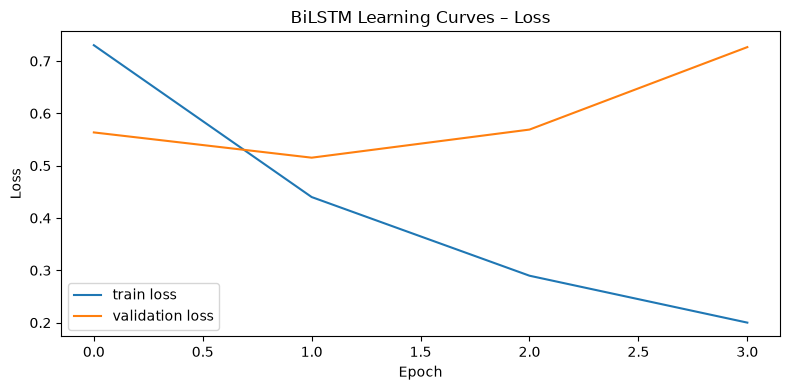

In [39]:
# Cell 39 – BiLSTM learning curves

history_df = pd.DataFrame(history.history)

plt.figure(figsize=(8, 4))
plt.plot(history_df["loss"], label="train loss")
plt.plot(history_df["val_loss"], label="validation loss")
plt.title("BiLSTM Learning Curves – Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT, "08_bilstm_learning_curves_loss.png"), dpi=200)
plt.show()


In [40]:
# Cell 40 – BiLSTM test evaluation

bilstm_test_start = time.perf_counter()
bilstm_probs = bilstm.predict(Xte, verbose=0)
bilstm_latency = time.perf_counter() - bilstm_test_start

bilstm_pred_ids = bilstm_probs.argmax(axis=1)
bilstm_pred = le.inverse_transform(bilstm_pred_ids)

bilstm_macro_f1 = f1_score(y_test, bilstm_pred, average="macro")
bilstm_weighted_f1 = f1_score(y_test, bilstm_pred, average="weighted")
bilstm_accuracy = accuracy_score(y_test, bilstm_pred)

print("BiLSTM Macro F1:", round(bilstm_macro_f1, 4))
print("BiLSTM Weighted F1:", round(bilstm_weighted_f1, 4))
print("BiLSTM Accuracy:", round(bilstm_accuracy, 4))
print("Batch inference time:", round(bilstm_latency, 4), "seconds")


BiLSTM Macro F1: 0.7378
BiLSTM Weighted F1: 0.791
BiLSTM Accuracy: 0.7883
Batch inference time: 10.6233 seconds


## 28. Advanced B – Twitter-domain Transformer

The manual prefers a Twitter-domain pretrained model such as:
- `vinai/bertweet-base`
- `cardiffnlp/twitter-roberta-base`

Use the same frozen test set as the classical models.

Record the exact checkpoint and configuration used.


In [41]:
# Cell 41 – Transformer imports and configuration

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
import evaluate

MODEL_NAME = "vinai/bertweet-base"  # Record exact checkpoint/version used

print("Transformer checkpoint:", MODEL_NAME)


Transformer checkpoint: vinai/bertweet-base


In [42]:
# Cell 42 – Recreate train/test split and Transformer validation split

import re
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset

# Reproducibility
SEED = 42

# ---------------------------------------------------------
# 1. Load the Twitter US Airline Sentiment dataset
# ---------------------------------------------------------

DATA_PATH = "Tweets.csv"

raw = pd.read_csv(DATA_PATH)

print("Original dataset shape:", raw.shape)

# ---------------------------------------------------------
# 2. Select required columns
# ---------------------------------------------------------

TEXT_COL = "text"
TARGET_COL = "airline_sentiment"

data = raw[[TEXT_COL, TARGET_COL]].copy()

# Remove missing values
data = data.dropna(subset=[TEXT_COL, TARGET_COL]).reset_index(drop=True)

# ---------------------------------------------------------
# 3. Minimal tweet normalization
# ---------------------------------------------------------

def clean_tweet(text):
    text = str(text)

    # Normalize URLs
    text = re.sub(r"https?://\S+|www\.\S+", " <URL> ", text)

    # Normalize mentions
    text = re.sub(r"@\w+", " <USER> ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

data[TEXT_COL] = data[TEXT_COL].apply(clean_tweet)

print("Clean dataset shape:", data.shape)

# ---------------------------------------------------------
# 4. Create locked train/test split
# ---------------------------------------------------------

X = data[TEXT_COL]
y = data[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("\nCore split:")
print("Training:", len(X_train))
print("Test:", len(X_test))

# ---------------------------------------------------------
# 5. Create Transformer validation split
#    ONLY from training data
# ---------------------------------------------------------

tr_text, val_text, tr_y_raw, val_y_raw = train_test_split(
    X_train,
    y_train,
    test_size=0.15,
    random_state=SEED,
    stratify=y_train
)

print("\nTransformer split:")
print("Transformer training:", len(tr_text))
print("Validation:", len(val_text))
print("Locked test:", len(X_test))

# ---------------------------------------------------------
# 6. Encode labels
# ---------------------------------------------------------

le_tf = LabelEncoder()
le_tf.fit(y_train)

print("\nLabel mapping:")
for i, label in enumerate(le_tf.classes_):
    print(i, "=", label)

# ---------------------------------------------------------
# 7. Create Hugging Face datasets
# ---------------------------------------------------------

train_tmp = pd.DataFrame({
    "text": tr_text.to_numpy(),
    "label": le_tf.transform(tr_y_raw)
})

val_tmp = pd.DataFrame({
    "text": val_text.to_numpy(),
    "label": le_tf.transform(val_y_raw)
})

test_tmp = pd.DataFrame({
    "text": X_test.to_numpy(),
    "label": le_tf.transform(y_test)
})

train_ds = Dataset.from_pandas(
    train_tmp,
    preserve_index=False
)

val_ds = Dataset.from_pandas(
    val_tmp,
    preserve_index=False
)

test_ds = Dataset.from_pandas(
    test_tmp,
    preserve_index=False
)

print("\nDatasets created successfully:")
print("Train:", train_ds)
print("Validation:", val_ds)
print("Test:", test_ds)

Original dataset shape: (14640, 15)
Clean dataset shape: (14640, 2)

Core split:
Training: 11712
Test: 2928

Transformer split:
Transformer training: 9955
Validation: 1757
Locked test: 2928

Label mapping:
0 = negative
1 = neutral
2 = positive

Datasets created successfully:
Train: Dataset({
    features: ['text', 'label'],
    num_rows: 9955
})
Validation: Dataset({
    features: ['text', 'label'],
    num_rows: 1757
})
Test: Dataset({
    features: ['text', 'label'],
    num_rows: 2928
})


In [43]:
from datasets.utils.logging import disable_progress_bar

disable_progress_bar()

In [44]:
!pip3 install emoji

In [ ]:
# Cell 43 – Transformer tokenizer

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

MODEL_NAME = "vinai/bertweet-base"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=False
)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128
    )

train_ds = train_ds.map(
    tokenize,
    batched=True
)

val_ds = val_ds.map(
    tokenize,
    batched=True
)

test_ds = test_ds.map(
    tokenize,
    batched=True
)

print("Tokenization complete.")

In [1]:
# Cell 44 – Transformer model

tf_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(le_tf.classes_),
    id2label={
        i: label for i, label in enumerate(le_tf.classes_)
    },
    label2id={
        label: i for i, label in enumerate(le_tf.classes_)
    }
)

print("Labels:", le_tf.classes_)
print("Transformer model loaded successfully.")

NameError: name 'AutoModelForSequenceClassification' is not defined

In [ ]:
# Cell 45 – Transformer metrics

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )["accuracy"]

    macro_f1 = f1_metric.compute(
        predictions=predictions,
        references=labels,
        average="macro"
    )["f1"]

    weighted_f1 = f1_metric.compute(
        predictions=predictions,
        references=labels,
        average="weighted"
    )["f1"]

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    }


In [ ]:
# Cell 46 – Transformer training

transformer_args = TrainingArguments(
    output_dir=os.path.join(OUT, "transformer"),
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    report_to="none",
    seed=SEED
)

trainer = Trainer(
    model=tf_model,
    args=transformer_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

transformer_start = time.perf_counter()
trainer.train()
transformer_train_time = time.perf_counter() - transformer_start

print("Training time:", round(transformer_train_time, 2), "seconds")


In [ ]:
# Cell 47 – Locked-test Transformer evaluation

test_eval = trainer.evaluate(test_ds)

print("Locked-test Transformer results:")
print(test_eval)

test_output = trainer.predict(test_ds)
tf_pred_ids = np.argmax(test_output.predictions, axis=1)
tf_pred = le_tf.inverse_transform(tf_pred_ids)

tf_macro_f1 = f1_score(y_test, tf_pred, average="macro")
tf_weighted_f1 = f1_score(y_test, tf_pred, average="weighted")
tf_accuracy = accuracy_score(y_test, tf_pred)

print("Macro F1:", round(tf_macro_f1, 4))
print("Weighted F1:", round(tf_weighted_f1, 4))
print("Accuracy:", round(tf_accuracy, 4))


## 29. Advanced uncertainty – three-seed requirement

For BiLSTM/Transformer comparisons, the manual requires either:
- at least three independent random seeds, or
- a justified bootstrap 95% confidence interval on the frozen test set.

The simplest classroom approach is to repeat the advanced model with seeds 42, 43 and 44 and report mean ± SD.


In [ ]:
# Cell 48 – Three-seed reporting template

advanced_seed_results = pd.DataFrame([
    {"model": "BiLSTM", "seed": 42, "macro_f1": np.nan},
    {"model": "BiLSTM", "seed": 43, "macro_f1": np.nan},
    {"model": "BiLSTM", "seed": 44, "macro_f1": np.nan},
    {"model": "BERTweet/Twitter-RoBERTa", "seed": 42, "macro_f1": np.nan},
    {"model": "BERTweet/Twitter-RoBERTa", "seed": 43, "macro_f1": np.nan},
    {"model": "BERTweet/Twitter-RoBERTa", "seed": 44, "macro_f1": np.nan},
])

print("Fill the actual results after repeating training.")
display(advanced_seed_results)

advanced_seed_results.to_csv(
    os.path.join(OUT, "advanced_three_seed_results.csv"),
    index=False
)


## 30. Advanced efficiency comparison


In [ ]:
# Cell 49 – Classical vs advanced efficiency template

efficiency = pd.DataFrame([
    {
        "model": "LinearSVC",
        "macro_f1": test_macro_f1 if best_name == "LinearSVC" else np.nan,
        "training_time_sec": np.nan,
        "inference_time_sec": np.nan,
        "model_size_mb": np.nan
    },
    {
        "model": "BiLSTM",
        "macro_f1": bilstm_macro_f1 if "bilstm_macro_f1" in globals() else np.nan,
        "training_time_sec": bilstm_time if "bilstm_time" in globals() else np.nan,
        "inference_time_sec": bilstm_latency if "bilstm_latency" in globals() else np.nan,
        "model_size_mb": np.nan
    },
    {
        "model": "BERTweet/Twitter-RoBERTa",
        "macro_f1": tf_macro_f1 if "tf_macro_f1" in globals() else np.nan,
        "training_time_sec": transformer_train_time if "transformer_train_time" in globals() else np.nan,
        "inference_time_sec": np.nan,
        "model_size_mb": np.nan
    }
])

display(efficiency)
efficiency.to_csv(
    os.path.join(OUT, "advanced_efficiency_comparison.csv"),
    index=False
)


## 32. One-cell artifact check

This final cell checks that the important core artifacts were generated.


In [ ]:
# Cell 50 – Artifact check

import os
import pandas as pd

# Define the output directory
OUT = "outputs"

# Create output directory if it does not already exist
os.makedirs(OUT, exist_ok=True)


# ============================================================
# CORE ARTIFACTS
# ============================================================

core_required_files = [
    "dataset_card.json",
    "train_manifest.csv",
    "test_manifest.csv",
    "cv_results.csv",
    "per_class_metrics.csv",
    "test_predictions.csv",
    "inspected_errors_10.csv",
    "challenge_analysis.csv",
    "entity_error_analysis.csv",
    "entity_sentiment_distribution.csv",
    "selected_pipeline.joblib",
    "new_tweet_predictions.csv",
    "final_metrics.json"
]

core_status = pd.DataFrame({
    "artifact": core_required_files,
    "exists": [
        os.path.exists(os.path.join(OUT, f))
        for f in core_required_files
    ]
})


# ============================================================
# OPTIONAL ARTIFACT
# ============================================================

optional_files = [
    "label_harmonization.csv"
]

optional_status = pd.DataFrame({
    "artifact": optional_files,
    "exists": [
        os.path.exists(os.path.join(OUT, f))
        for f in optional_files
    ]
})


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("=" * 60)
print("CORE ARTIFACT STATUS")
print("=" * 60)

display(core_status)

print("\n" + "=" * 60)
print("OPTIONAL ARTIFACT STATUS")
print("=" * 60)

display(optional_status)


# ============================================================
# FINAL CHECK
# ============================================================

core_passed = core_status["exists"].all()

print("\n" + "=" * 60)

if core_passed:
    print("Core artifact check: PASSED")
else:
    print("Core artifact check: INCOMPLETE")

missing_core = core_status.loc[
    ~core_status["exists"], "artifact"
].tolist()

if missing_core:
    print("\nMissing core artifacts:")
    for f in missing_core:
        print(" -", f)

print("=" * 60)

# End of Notebook

**Core experiment is complete after Cell 33 plus the required checklist/artifact check.**

Cells 35 onward are the advanced BiLSTM/Transformer extension and should be run only if assigned or if GPU/runtime resources are available.
